In [1]:
# ── Cell 0: Fix working directory ──────────────────────────────────────────
# Jupyter kernels start in the notebook's own directory (ml/notebooks/).
# We change to the project root so all relative paths work correctly.
import os, pathlib

# Walk up until we find the project root (identified by 'requirements.txt')
root = pathlib.Path(os.getcwd())
while not (root / 'requirements.txt').exists():
    root = root.parent
os.chdir(root)
print(f'Working directory set to: {os.getcwd()}')

Working directory set to: d:\Jeet\projects\Data_Science\Project\Project_Medical_Image_Classification


In [2]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

DATA_ROOT = pathlib.Path('ml/data/raw')
REPORT_DIR = pathlib.Path('ml/reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Cell 2 - Count images per split and class
IMAGE_EXTS = ['*.jpeg', '*.jpg', '*.png']
splits = ['train', 'val', 'test']
classes = ['NORMAL', 'PNEUMONIA']

def count_images(folder):
    folder = pathlib.Path(folder)
    return sum(len(list(folder.glob(ext))) for ext in IMAGE_EXTS)

counts = {s: {c: count_images(DATA_ROOT / s / c) for c in classes} for s in splits}
for s, cls_counts in counts.items():
    print(f'{s.upper():6s}: {cls_counts}')

TRAIN : {'NORMAL': 1341, 'PNEUMONIA': 3875}
VAL   : {'NORMAL': 8, 'PNEUMONIA': 8}
TEST  : {'NORMAL': 234, 'PNEUMONIA': 390}


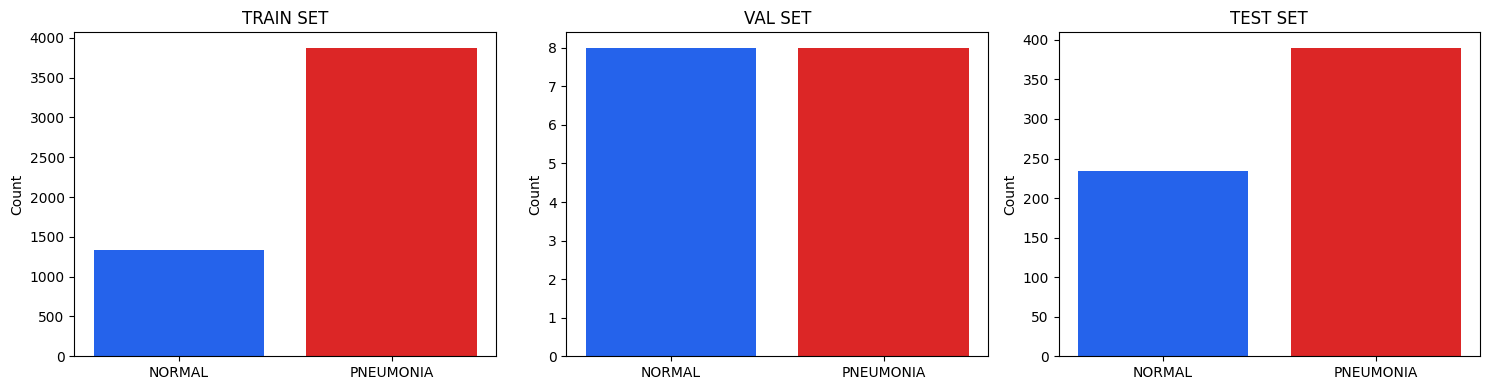

Saved -> ml\reports/class_distribution.png


In [4]:
# Cell 3 - Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, splits):
    ax.bar(classes, [counts[split][c] for c in classes],
           color=['#2563EB','#DC2626'])
    ax.set_title(f'{split.upper()} SET')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'class_distribution.png')
plt.show()
print(f'Saved -> {REPORT_DIR}/class_distribution.png')

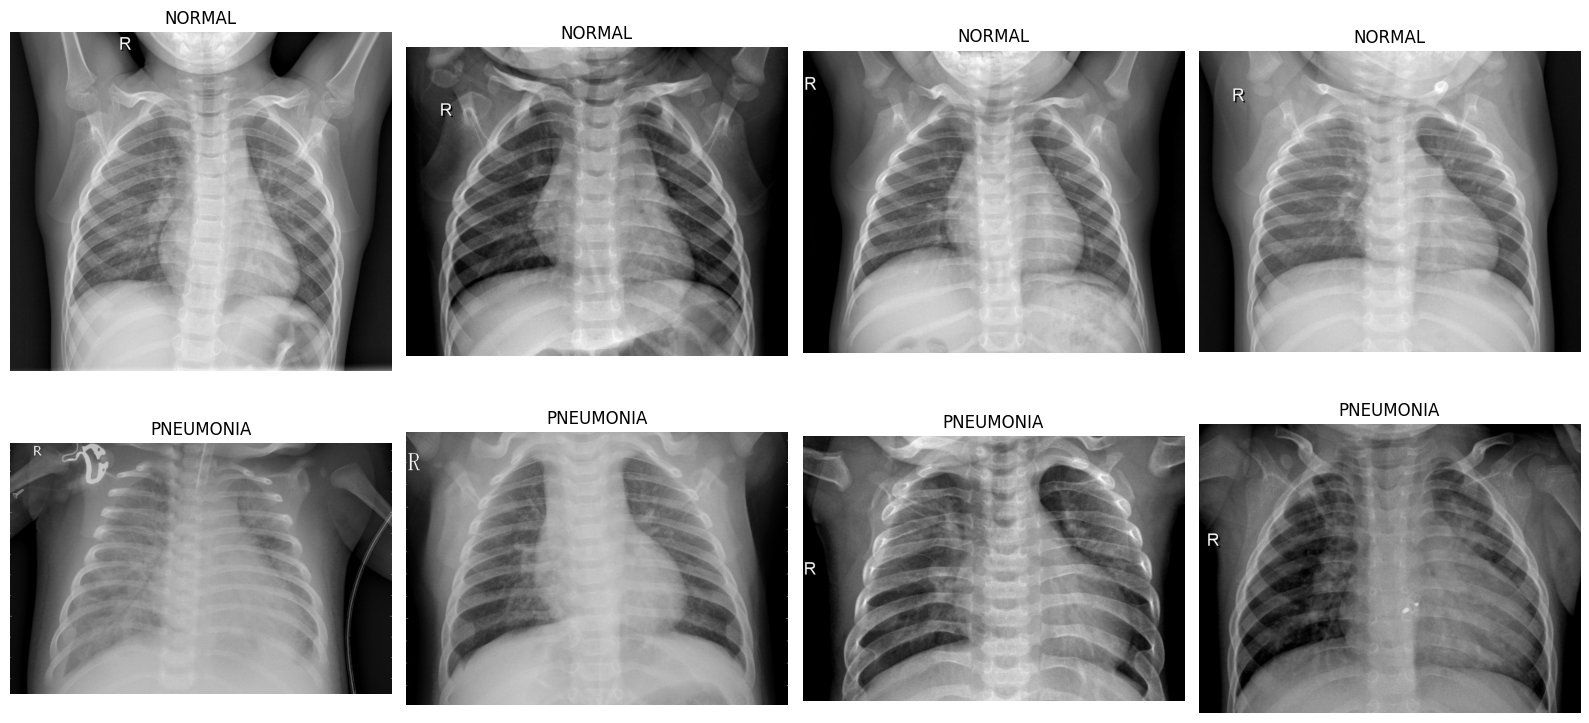

Saved -> ml\reports/sample_images.png


In [5]:
# Cell 4 - Display sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, cls in enumerate(classes):
    folder = DATA_ROOT / 'train' / cls
    imgs = []
    for ext in IMAGE_EXTS:
        imgs.extend(list(folder.glob(ext)))
    imgs = sorted(imgs)[:4]
    for j, img_path in enumerate(imgs):
        ax = axes[i][j]
        ax.imshow(Image.open(img_path), cmap='gray')
        ax.set_title(f'{cls}'); ax.axis('off')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'sample_images.png')
plt.show()
print(f'Saved -> {REPORT_DIR}/sample_images.png')

In [6]:
# Cell 5 - Image size distribution
sizes = []
for ext in IMAGE_EXTS:
    for img_path in (DATA_ROOT / 'train' / 'NORMAL').glob(ext):
        sizes.append(Image.open(img_path).size)
widths, heights = zip(*sizes)
print(f'Width  - min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.0f}')
print(f'Height - min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.0f}')

Width  - min:912, max:2916, mean:1668
Height - min:672, max:2663, mean:1381
